# Week 4: Logistic Regression on the Titanic Dataset

## Objective

The objective of this notebook is to build a supervised machine learning classification model capable of predicting whether a Titanic passenger survived based on available passenger information.

The workflow includes:

- Loading and inspecting the Titanic dataset
- Checking and handling missing values
- Removing irrelevant features
- Encoding categorical variables
- Separating features and target variables
- Splitting the data into training and testing sets
- Training a Logistic Regression model
- Making predictions
- Evaluating the model using Accuracy Score
- Interpreting the model results

Import Libraries 

In [74]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [75]:
titanic = pd.read_csv("../data/cleaned/titanic_cleaned.csv")

In [76]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [77]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [78]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Data Preprocessing

In [79]:
titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

One hot encoding

In [80]:
titanic = pd.get_dummies(titanic, columns= ["Sex", "Embarked"], drop_first=True, dtype=int)
titanic.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,0,1


In [81]:
titanic.duplicated().sum()

np.int64(0)

In [82]:
titanic = titanic.drop(columns=["PassengerId", "Name", "Ticket"])

In [83]:
# Prevent re-encoding if the categorical columns were already converted
if {"Sex", "Embarked"}.issubset(titanic.columns):
    titanic = pd.get_dummies(titanic, columns=["Sex", "Embarked"], drop_first=True, dtype=int)
else:
    print("Categorical columns already encoded; skipping one-hot encoding.")
titanic.head()

Categorical columns already encoded; skipping one-hot encoding.


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


Separate Features x and target y

In [84]:
x = titanic.drop("Survived", axis=1)
y=titanic["Survived"]

In [85]:
x.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,3,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,1
4,3,35.0,0,0,8.0500,1,0,1


In [86]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

# Train/Test Split

In [87]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [88]:
print(f"x_train shape: {x_train.shape}")
print(f"x_test.shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (712, 8)
x_test.shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


## Train the Logistic Regression Model

In [89]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## 8. Make Predictions

The trained Logistic Regression model is used to predict the survival status of passengers in the test dataset. The model produces a binary prediction where `0` represents that a passenger did not survive and `1` represents that the passenger survived.

In [90]:
y_pred = model.predict(x_test)

In [91]:
y_pred[: 10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [92]:
comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})
comparison.head(10)

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


## 9. Evaluate the Model

Accuracy Score is used to evaluate the Logistic Regression model. Accuracy measures the proportion of test observations that were correctly classified by the model.

It is calculated as:

\[
Accuracy = \frac{\text{Correct Predictions}}{\text{Total Predictions}}
\]

A higher accuracy indicates that the model correctly classified a larger proportion of the test observations.

In [93]:
accuracy =accuracy_score(y_test, y_pred)

print(f"Accuracy Score: {accuracy:.4f}")
print(f"Accuracy Score: {accuracy * 100:.2f}%")

Accuracy Score: 0.8101
Accuracy Score: 81.01%


In [94]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[90 15]
 [19 55]]


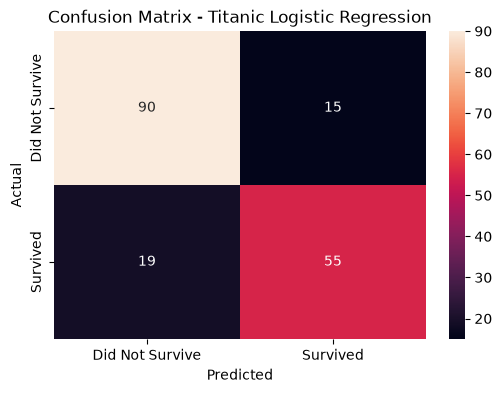

In [95]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Titanic Logistic Regression")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows how the Logistic Regression model classified the passengers in the test dataset.

The model correctly classified **90 passengers who did not survive** and **55 passengers who survived**. These are the true negative and true positive predictions respectively.

The model incorrectly predicted that **15 passengers survived when they did not**, representing false positive predictions. It also predicted that **19 passengers did not survive when they actually survived**, representing false negative predictions.

Overall, the model correctly classified **145 out of 179 test passengers**, resulting in an accuracy of **81.01%**.

## Conclusion

In this notebook, a Logistic Regression model was developed to predict passenger survival using the Titanic dataset. The dataset was inspected and preprocessed by removing irrelevant identifier and text-based columns and encoding categorical variables using One-Hot Encoding.

The target variable was `Survived`, while `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`, `Sex_male`, `Embarked_Q`, and `Embarked_S` were used as predictive features. The dataset was divided into training and testing sets using an 80/20 split with `random_state=42`.

A Logistic Regression model was trained on the training data and used to predict the survival status of passengers in the test dataset. The model achieved an **Accuracy Score of 81.01%**.

The confusion matrix showed that the model correctly classified **90 passengers who did not survive** and **55 passengers who survived**. It incorrectly classified **15 passengers as survivors when they did not survive** and **19 passengers as non-survivors when they actually survived**.

Overall, the model correctly classified **145 out of 179 passengers** in the test set, demonstrating that Logistic Regression was able to identify useful patterns between passenger characteristics and survival status.

This project demonstrated the complete supervised learning workflow for a classification problem, including data preprocessing, categorical encoding, feature and target selection, train/test splitting, model training, prediction, and evaluation.

A limitation of the model is that it only uses the features available in the dataset. Additional feature engineering and evaluation metrics such as precision, recall, F1-score, and ROC-AUC could be explored in future work to provide a more comprehensive assessment of classification performance.